In [12]:
# ── 표준 라이브러리
import pickle

# ── 서드파티 라이브러리
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from pandas import DataFrame, merge

# ── scikit-learn: 파이프라인 & 전처리
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ── scikit-learn: 모델 선택 & 검증
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
)

# ── scikit-learn: 평가 지표
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

# ── scikit-learn: 모델
from sklearn.ensemble import BaggingRegressor
from sklearn.neighbors import KNeighborsRegressor

# ── 사용자 정의 모듈
from hossam import *


## 성능 평가 함수

### VIF 필터링 클래스

In [29]:
from sklearn.base import BaseEstimator, TransformerMixin


class VIFSelector(BaseEstimator, TransformerMixin):
    """
    VIF 기준으로 다중공선성이 높은 변수를 제거하는 Transformer
    """

    def __init__(self, threshold=10.0, check_cols=None):
        self.threshold = threshold
        self.check_cols = check_cols

    def fit(self, X, y=None):
        # 실제 구현부 (생략)
        return self

    def transform(self, X):
        # 실제 구현부 (생략)
        return X


### 성능평가 함수

In [30]:
def hs_get_scores(estimator, X_test, y_true):
    """
    테스트 데이터 기준 성능 평가 함수
    """
    # 실제 구현부 (생략)
    pass


### 과적합 판정 함수

In [31]:
import numpy as np


def hs_learning_cv(
    estimator,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
):
    """
    Learning Curve 기반 과적합 판단 함수
    """
    # 실제 구현부 (생략)
    pass


### 데이터 가져오기 + 인덱스, 타입변환

In [27]:
# 데이터 로드
origin = load_data("restaurant_sales_preprocessed")

# 날짜 컬럼 파싱
origin.set_index("date", inplace=True)

# 범주형 변수 타입 변환
origin["holiday"] = origin["holiday"].astype("category")
origin["weekend"] = origin["weekend"].astype("category")

# 데이터 구조 확인
origin.info()


어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sales           353 non-null    float64 
 1   visitors        353 non-null    int64   
 2   avg_price       353 non-null    int64   
 3   marketing_cost  353 non-null    float64 
 4   delivery_ratio  353 non-null    float64 
 5   rain_mm         353 non-null    float64 
 6   temperature     353 non-null    float64 
 7   holiday         353 non-null    category
 8   weekend         353 non-null    category
dtypes: category(2), float64(5), int64(2)
memory usage: 23.0 KB


### 훈련,학습데이터 분리

In [28]:
# 원본 데이터 참조
df = origin

# 타깃 / 피처 분리
y_name = "sales"
X = df.drop(columns=y_name)
y = df[y_name]

# Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=52,
)

# 데이터 크기 확인
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((264, 8), (89, 8), (264,), (89,))

## Bagging 후보 선정

### 성능 비교표 데이터프레임

In [43]:
from pandas import DataFrame
score_df = DataFrame(
    [
        [
            "Linear",
            0.709, 0.156, 0.042, 0.204, 0.010, 0.225,
            0.198, 0.203, 0.012, 0.973, 0.060,
            "⚠️ 과대적합",
        ],
        [
            "Ridge",
            0.708, 0.156, 0.042, 0.205, 0.010, 0.219,
            0.198, 0.203, 0.012, 0.974, 0.058,
            "⚠️ 과대적합",
        ],
        [
            "Lasso",
            0.707, 0.155, 0.042, 0.205, 0.009, 0.221,
            0.199, 0.204, 0.011, 0.978, 0.055,
            "⚠️ 과대적합",
        ],
        [
            "ElasticNet",
            0.709, 0.156, 0.042, 0.204, 0.010, 0.223,
            0.198, 0.203, 0.012, 0.974, 0.059,
            "⚠️ 과대적합",
        ],
        [
            "SGD",
            0.700, 0.160, 0.043, 0.207, 0.010, 0.229,
            0.203, 0.210, 0.010, 0.964, 0.046,
            "⚠️ 과대적합",
        ],
        [
            "KNN",
            0.635, 0.178, 0.052, 0.229, 0.011, 0.301,
            0.000, 0.220, 0.020, 0.000, 0.090,
            "⚠️ 과대적합 (variance 큼)",
        ],
        [
            "DecisionTree",
            0.620, 0.196, 0.054, 0.233, 0.012, 0.353,
            0.224, 0.245, 0.018, 0.912, 0.072,
            "✅ 일반화 양호",
        ],
        [
            "SVR",
            0.701, 0.157, 0.043, 0.207, 0.010, 0.233,
            0.196, 0.206, 0.011, 0.949, 0.055,
            "✅ 일반화 양호",
        ],
    ],
    columns=[
        "모델",
        "결정계수(R2)",
        "MAPE",
        "MAE",
        "MSE",
        "RMSE",
        "CV RMSE 평균",
        "CV RMSE 표준편차",
        "Train/CV 비율",
        "CV 변동성 비율",
        "판정 결과",
    ],
)

score_df
   


ValueError: 11 columns passed, passed data had 13 columns

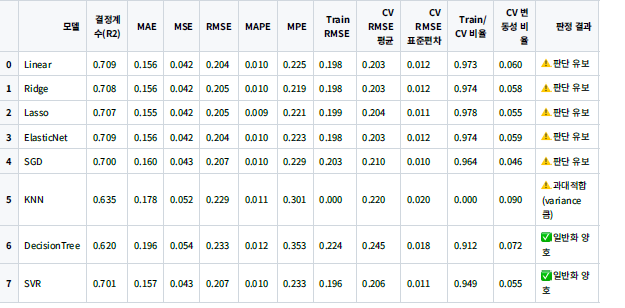

### Bagging 후보 선정 기준

In [38]:
# 원본 보호
df = score_df.copy()

# ── ① 학습–검증 괴리
cond_train_cv = df["Train/CV 비율"] <= 0.95

# ── ② 교차검증 변동성
cond_cv_var = df["CV 변동성 비율"] >= 0.07

# ── ③ 정성 판정 (텍스트 기반)
cond_text = df["판정 결과"].str.contains(
    "variance|과대적합",
    regex=True,
)

# ── ④ 모델 특성 (고분산 구조)
cond_model_type = df["모델"].str.contains(
    "KNN|Tree",
    regex=True,
)

# ── 배깅 후보 여부 플래그
df["배깅_후보"] = (
    cond_train_cv
    | cond_cv_var
    | cond_text
    | cond_model_type
)

# ── 배깅 후보 추출 및 정렬
bagging_candidates = (
    df[df["배깅_후보"]]
    .sort_values(
        by=["CV 변동성 비율", "Train/CV 비율"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

bagging_candidates


NameError: name 'score_df' is not defined